In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd

ENTITY_COUNTS_PATH = '/content/gdrive/MyDrive/slovene_data_2025/slovene_entity_counts.csv'
EVENTS_PATH = '/content/gdrive/MyDrive/slovene_data_2025/extracted_events_by_topics.csv'

sentiment =  pd.read_csv('/content/gdrive/MyDrive/slovene_data_2025/slovene_entity_counts.csv') # gives us sentiment
events = pd.read_csv('/content/gdrive/MyDrive/slovene_data_2025/extracted_event_2.csv')

In [ ]:
import argparse
import re
from pathlib import Path
from typing import Optional, Tuple

import matplotlib
import pandas as pd


import matplotlib.pyplot as plt


def load_entity_counts(path: Path, topic_ids=None) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.columns[0] == "":
        df = df.drop(columns=df.columns[0])
    datetime = '1/1/2022'

    df["date"] = pd.to_datetime(df["date"], format='%d-%m-%Y', errors='coerce')
    df = df[df["date"].notna()]

    if topic_ids:
      topic_assignments = pd.read_csv('/content/gdrive/MyDrive/slovene_data_2025/bertopic_topic_assignments_1511_with_ids.csv')

      merged_df = pd.merge(df, topic_assignments[['Topic', 'id']], left_on='document_id', right_on='id', how='inner')
      merged_df = merged_df[merged_df['Topic'].isin(topic_ids)]
      return merged_df
    else:
      return df


def load_events(path: Path, topic_ids = None) -> pd.DataFrame:
    events = pd.read_csv(path, dayfirst=True)
    datetime = '1/1/2022'
    events["date"] = pd.to_datetime(events["date"], format='%Y-%m-%d')
    events["date"] = pd.to_datetime(events["date"], errors='coerce').fillna(pd.to_datetime(datetime))
    events=events.groupby('date').first().reset_index()

    if topic_ids:
        events = events[events["topic_id"].isin(topic_ids)]
    return events


def build_entity_series(
    entity_counts: pd.DataFrame,
    entity: str,
) -> pd.DataFrame:
    mask = entity_counts["entity"].astype(str).str.contains(
        re.escape(entity), case=False, na=False
    )
    filtered = entity_counts[mask]
    if filtered.empty:
        raise ValueError(f"No rows found for entity '{entity}'")
    series = (
        filtered.groupby("date", as_index=False)["frequency"]
        .sum()
        .sort_values("date")
        .reset_index(drop=True)
    )
    return series


def detect_spikes(
    series: pd.DataFrame,
    window: int,
    z_threshold: float,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    working = series.copy()
    working["rolling_mean"] = working["frequency"].rolling(
        window=window, center=True, min_periods=1
    ).mean()
    working["rolling_std"] = working["frequency"].rolling(
        window=window, center=True, min_periods=1
    ).std(ddof=0)
    working["z_score"] = (working["frequency"] - working["rolling_mean"]) / working[
        "rolling_std"
    ].replace(0, pd.NA)
    spikes = working[working["z_score"] >= z_threshold]
    return working, spikes


def annotate_spikes(
    spikes: pd.DataFrame,
    events: pd.DataFrame,
) -> pd.DataFrame:
    merged = spikes.merge(events, on="date", how="left")
    merged = merged.rename(columns={"event_summary": "event"})
    merged["event"] = merged["event"].fillna("")

    print("Merged", merged)
    return merged


def plot_series(
    series: pd.DataFrame,
    spikes: pd.DataFrame,
    entity: str,
    output_path: Optional[Path],
    show_inline: bool,
) -> None:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(series["date"], series["frequency"], label="Frequency", color="#1f77b4")

    if not spikes.empty:
        ax.scatter(
            spikes["date"],
            spikes["frequency"],
            color="#d62728",
            label="Spikes",
            zorder=5,
        )

        # --- Calculate padding based on data range ---
        y_min, y_max = series["frequency"].min(), series["frequency"].max()
        y_padding = (y_max - y_min) * 0.15  # add 15% padding top and bottom
        ax.set_ylim(y_min - y_padding, y_max + y_padding)

        # --- Annotate spikes ---
        offsets = [
            (0, 20), (0, -26), (28, 20), (-28, 20),
            (28, -26), (-28, -26), (0, 38), (0, -44),
        ]
        label_idx = 0
        used_positions: list[tuple[pd.Timestamp, int, int]] = []

        for _, row in spikes.iterrows():
            event_text = (row.get("event") or "").strip()
            if not event_text:
                continue

            base_dx, base_dy = offsets[label_idx % len(offsets)]
            cycle = label_idx // len(offsets)
            extra = cycle * 14
            dy = base_dy + (extra if base_dy > 0 else -extra)
            dx = base_dx

            if dy == 0:
                dy = 18

            step = 18 if dy > 0 else -18
            attempts = 0
            while any(
                (
                    abs((row["date"] - prev_date).days) <= 1
                    and abs(dx - prev_dx) < 22
                    and abs(dy - prev_dy) < 20
                )
                for prev_date, prev_dx, prev_dy in used_positions
            ):
                dy += step
                attempts += 1
                if attempts > 6:
                    dx = -dx if dx != 0 else 24
            used_positions.append((row["date"], dx, dy))

            # Ensure labels stay within plot area
            y_val = row["frequency"]
            if y_val + dy / 50.0 > ax.get_ylim()[1]:
                dy = -abs(dy)
            elif y_val + dy / 50.0 < ax.get_ylim()[0]:
                dy = abs(dy)

            ha = "center"
            if dx > 0:
                ha = "left"
            elif dx < 0:
                ha = "right"
            va = "bottom" if dy > 0 else "top"

            ax.annotate(
                event_text,
                xy=(row["date"], row["frequency"]),
                xytext=(dx, dy),
                textcoords="offset points",
                ha=ha,
                va=va,
                fontsize=8,
                linespacing=1.3,
                color="#d62728",
                bbox={
                    "boxstyle": "round,pad=0.2",
                    "fc": "white",
                    "ec": "#d62728",
                    "lw": 0.6,
                },
                arrowprops={
                    "arrowstyle": "-",
                    "color": "#d62728",
                    "lw": 0.6,
                },
            )
            label_idx += 1

    ax.set_title(f"Entity frequency over time: {entity}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Frequency")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.autofmt_xdate()

    plt.tight_layout(pad=2.5)  # ← ensures nothing overlaps with labels

    if output_path:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
    elif show_inline:
        plt.show()
    else:
        default_path = Path("entity_timeseries.png")
        fig.savefig(default_path, dpi=200, bbox_inches="tight")
        print("Saved plot to entity_timeseries.png (default).")

    if show_inline and output_path:
        plt.show()

    plt.close(fig)



def run_analysis(
    entity: str,
    window: int = 7,
    z_threshold: float = 2.0,
    entity_counts_path: Path = Path("code/eng_data/eng_entity_counts_with_order.csv"),
    events_path: Path = Path("code/eng_data/extracted_event.csv"),
    output: Optional[Path] = None,
    spikes_output: Optional[Path] = None,
    show_inline: Optional[bool] = None,
    topic_ids = None
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    entity_counts = load_entity_counts(entity_counts_path, topic_ids)
    events = load_events(events_path,  topic_ids)
    series = build_entity_series(entity_counts, entity)
    working, spikes = detect_spikes(series, window, z_threshold)
    spikes_with_events = annotate_spikes(spikes, events)

    if spikes_output:
        spikes_output.parent.mkdir(parents=True, exist_ok=True)
        spikes_with_events.to_csv(spikes_output, index=False)

    inline = show_inline if show_inline is not None else False
    plot_series(working, spikes_with_events, entity, output, inline)
    return working, spikes_with_events

Merged          date  frequency  rolling_mean  rolling_std   z_score  Unnamed: 0  \
0  2022-02-24         25      8.452381     6.845932  2.417146       296.0   
1  2022-03-03         27      8.081633     6.561597  2.883195         NaN   
2  2022-03-06         20      7.880000     6.611021  1.833302         NaN   
3  2022-06-04          8      3.460000     2.282192  1.989316         NaN   
4  2022-06-06          8      3.380000     2.261769  2.042649         NaN   
5  2022-06-16          9      3.280000     2.298173  2.488933         NaN   
6  2022-06-17          9      3.280000     2.298173  2.488933         NaN   
7  2022-06-27          8      3.240000     2.276489  2.090940         NaN   
8  2022-07-20          8      2.820000     2.065817  2.507482         NaN   
9  2022-09-22          9      3.200000     2.366432  2.450947       417.0   
10 2022-09-27          8      3.320000     2.378571  1.967568         NaN   
11 2022-09-30         10      3.320000     2.353211  2.838675        

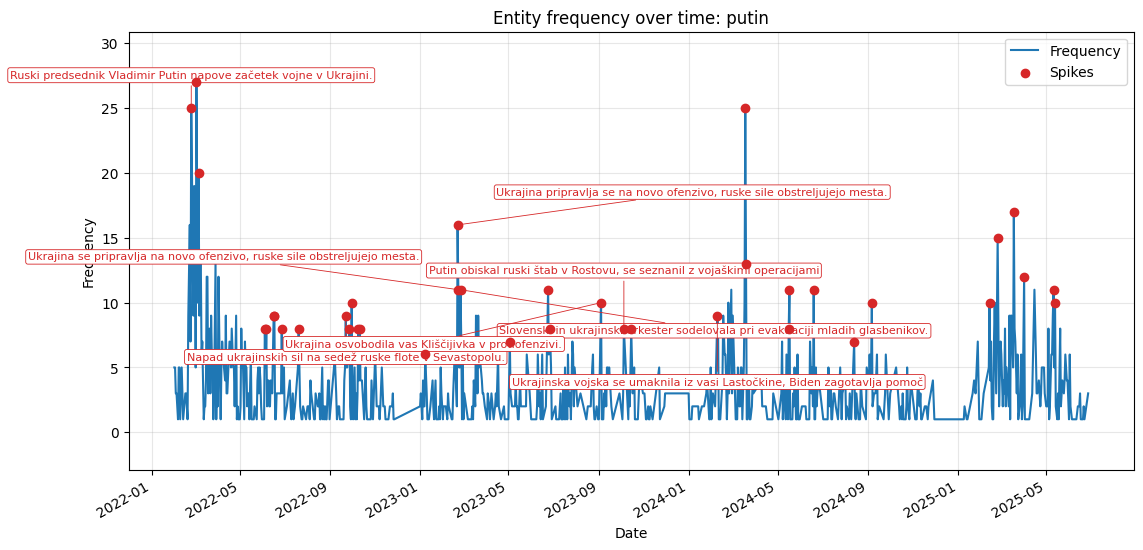

(          date  frequency  rolling_mean  rolling_std   z_score
 0   2022-02-01          5      8.440000     7.637172 -0.450428
 1   2022-02-02          5      8.807692     7.711227 -0.493786
 2   2022-02-03          3      8.851852     7.570428 -0.772988
 3   2022-02-04          3      9.250000     7.716518 -0.809951
 4   2022-02-06          1      9.241379     7.582444 -1.086903
 ..         ...        ...           ...          ...       ...
 707 2025-06-17          1      3.000000     2.236068 -0.894427
 708 2025-06-20          1      2.931034     2.242705 -0.861029
 709 2025-06-21          2      2.678571     1.833295 -0.370138
 710 2025-06-22          1      2.703704     1.862193 -0.914891
 711 2025-06-27          3      2.769231     1.866871  0.123613
 
 [712 rows x 5 columns],
          date  frequency  rolling_mean  rolling_std   z_score  Unnamed: 0  \
 0  2022-02-24         25      8.452381     6.845932  2.417146       296.0   
 1  2022-03-03         27      8.081633     6.561

In [ ]:

run_analysis('putin', window=50, z_threshold=1.8, entity_counts_path=ENTITY_COUNTS_PATH, events_path=EVENTS_PATH, show_inline=True, topic_ids=[-1, 0])

In [ ]:
1